In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from google.colab import drive
drive.mount('/content/drive')
# --- تحميل البيانات ---
X = np.load('/content/drive/MyDrive/alphabet/images_original.npy')
y = np.load('/content/drive/MyDrive/alphabet/encoded_labels_original.npy')

# لو الصور رمادية نكررها لثلاث قنوات
if X.shape[-1] == 1:
    X = np.repeat(X, 3, axis=-1)

# تقسيم البيانات
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

input_shape = X_train.shape[1:]
num_classes = len(np.unique(y))


Mounted at /content/drive


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)


In [ ]:
def build_mobilenetv2(input_shape, num_classes):
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    # Fine-tuning: نفتح آخر 20 طبقة
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    for layer in base_model.layers[-20:]:
        layer.trainable = True

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model



🚀 Run 1/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


534/534 ━━━━━━━━━━━━━━━━━━━━ 100s 143ms/step - accuracy: 0.2094 - loss: 3.3405 - val_accuracy: 0.4507 - val_loss: 2.0363 - learning_rate: 1.0000e-04
Epoch 2/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 49s 91ms/step - accuracy: 0.6053 - loss: 1.2821 - val_accuracy: 0.6681 - val_loss: 1.1879 - learning_rate: 1.0000e-04
Epoch 3/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 50s 94ms/step - accuracy: 0.7309 - loss: 0.8517 - val_accuracy: 0.8075 - val_loss: 0.6113 - learning_rate: 1.0000e-04
Epoch 4/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 49s 92ms/step - accuracy: 0.8005 - loss: 0.6160 - val_accuracy: 0.8635 - val_loss: 0.4283 - learning_rate: 1.0000e-04
Epoch 5/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 47s 88ms/step - accuracy: 0.8503 - loss: 0.4642 - val_accuracy: 0.9027 - val_loss: 0.3005 - learning_rate: 1.0000e-04
Epoch 6/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 49s 92ms/step - accuracy: 0.8767 - loss: 0.3874 - val_accuracy: 0.9328 - val_loss: 0.2072 - learning_rate: 1.0000e-04
Epoch 7/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 51s 96ms/step - accur

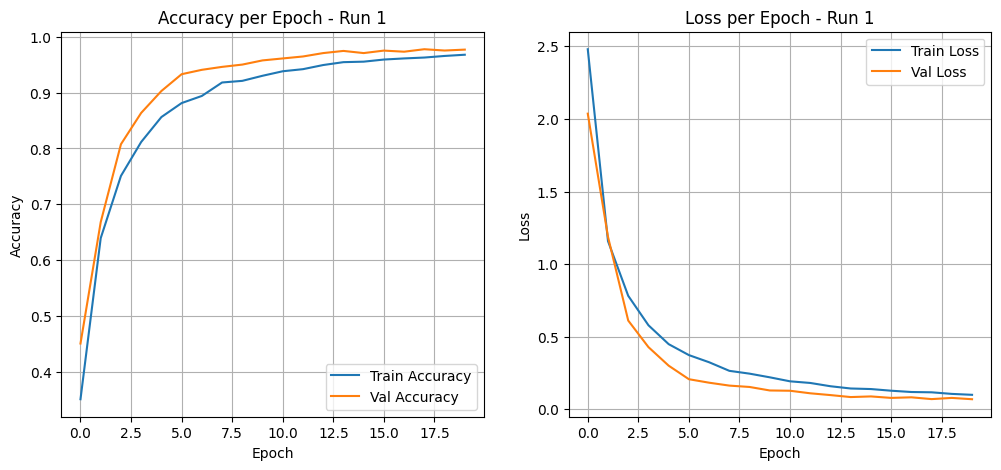

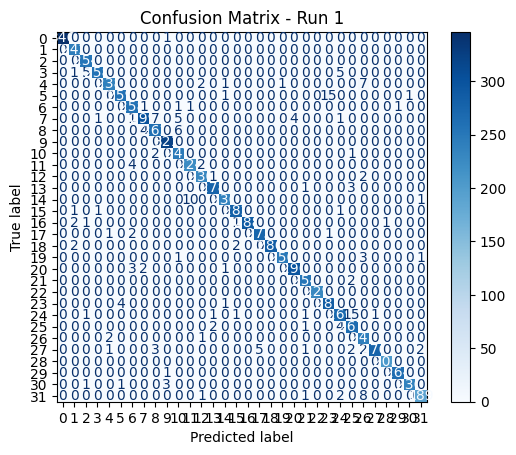


🚀 Run 2/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 72s 110ms/step - accuracy: 0.2008 - loss: 3.3911 - val_accuracy: 0.5027 - val_loss: 1.7769 - learning_rate: 1.0000e-04
Epoch 2/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 49s 91ms/step - accuracy: 0.5952 - loss: 1.3115 - val_accuracy: 0.6939 - val_loss: 1.0473 - learning_rate: 1.0000e-04
Epoch 3/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 47s 88ms/step - accuracy: 0.7277 - loss: 0.8462 - val_accuracy: 0.8038 - val_loss: 0.6499 - learning_rate: 1.0000e-04
Epoch 4/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 48s 90ms/step - accuracy: 0.7931 - loss: 0.6389 - val_accuracy: 0.8826 - val_loss: 0.3741 - learning_rate: 1.0000e-04
Epoch 5/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 48s 90ms/step - accuracy: 0.8467 - loss: 0.4758 - val_accuracy: 0.9013 - val_loss: 0.3157 - learning_rate: 1.0000e-04
Epoch 6/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 47s 88ms/step - accuracy: 0.8796 - loss: 0.3819 - val_accuracy: 0.9185 - val_loss: 0.2522 - learning_rate: 1.0000e-04
Epoch 7/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 48s 91ms/st

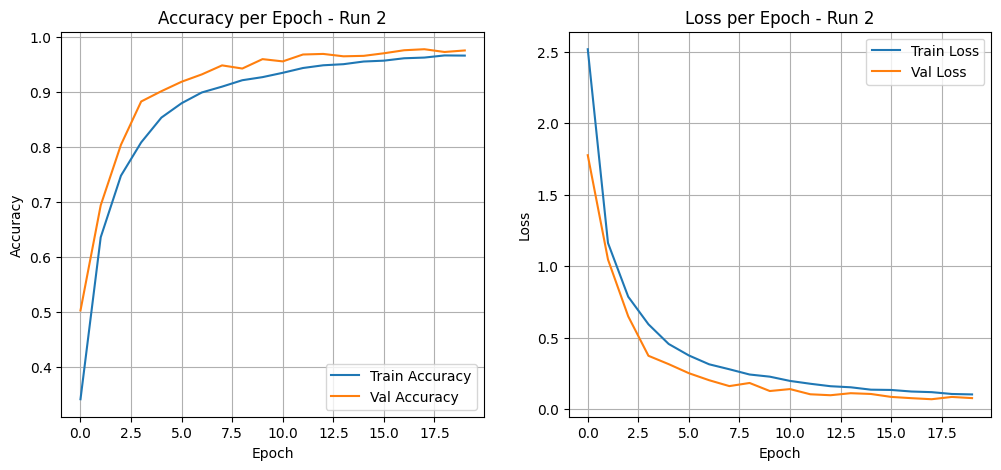

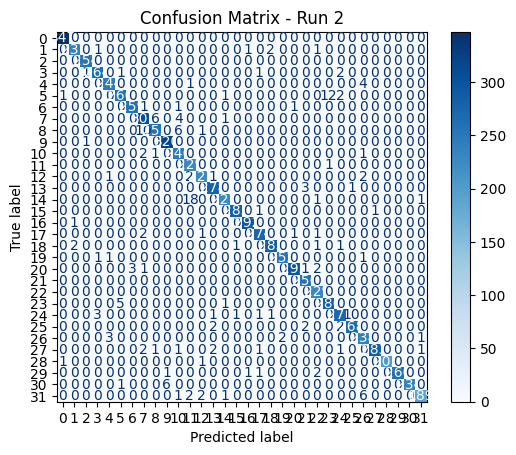


🚀 Run 3/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


534/534 ━━━━━━━━━━━━━━━━━━━━ 73s 111ms/step - accuracy: 0.2016 - loss: 3.3424 - val_accuracy: 0.4967 - val_loss: 1.7481 - learning_rate: 1.0000e-04
Epoch 2/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 50s 93ms/step - accuracy: 0.6018 - loss: 1.2983 - val_accuracy: 0.7020 - val_loss: 1.0406 - learning_rate: 1.0000e-04
Epoch 3/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 49s 92ms/step - accuracy: 0.7268 - loss: 0.8574 - val_accuracy: 0.8107 - val_loss: 0.6195 - learning_rate: 1.0000e-04
Epoch 4/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 48s 90ms/step - accuracy: 0.8010 - loss: 0.6075 - val_accuracy: 0.8750 - val_loss: 0.3996 - learning_rate: 1.0000e-04
Epoch 5/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 50s 93ms/step - accuracy: 0.8476 - loss: 0.4786 - val_accuracy: 0.9119 - val_loss: 0.2600 - learning_rate: 1.0000e-04
Epoch 6/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 49s 91ms/step - accuracy: 0.8737 - loss: 0.3991 - val_accuracy: 0.9345 - val_loss: 0.2013 - learning_rate: 1.0000e-04
Epoch 7/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 48s 89ms/step - accura

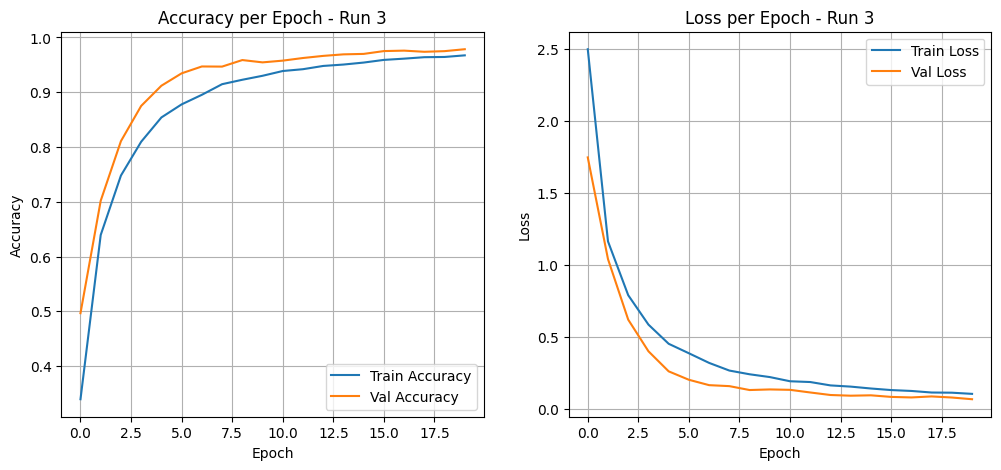

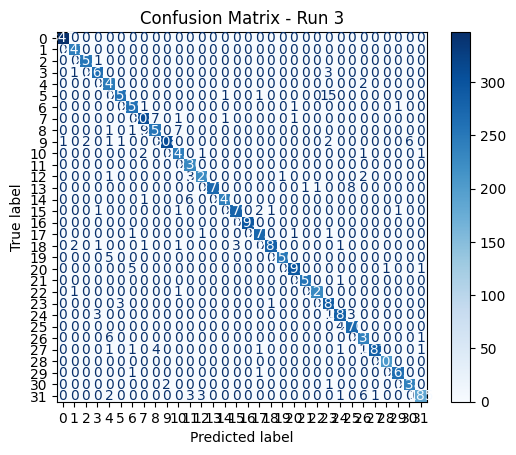


🚀 Run 4/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


534/534 ━━━━━━━━━━━━━━━━━━━━ 75s 115ms/step - accuracy: 0.2062 - loss: 3.3364 - val_accuracy: 0.5085 - val_loss: 1.7085 - learning_rate: 1.0000e-04
Epoch 2/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 51s 95ms/step - accuracy: 0.5979 - loss: 1.3088 - val_accuracy: 0.6753 - val_loss: 1.1260 - learning_rate: 1.0000e-04
Epoch 3/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 81s 93ms/step - accuracy: 0.7250 - loss: 0.8617 - val_accuracy: 0.8085 - val_loss: 0.6097 - learning_rate: 1.0000e-04
Epoch 4/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 49s 92ms/step - accuracy: 0.8021 - loss: 0.6223 - val_accuracy: 0.8762 - val_loss: 0.3962 - learning_rate: 1.0000e-04
Epoch 5/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 48s 89ms/step - accuracy: 0.8435 - loss: 0.4753 - val_accuracy: 0.9046 - val_loss: 0.2863 - learning_rate: 1.0000e-04
Epoch 6/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 50s 93ms/step - accuracy: 0.8699 - loss: 0.4035 - val_accuracy: 0.9194 - val_loss: 0.2412 - learning_rate: 1.0000e-04
Epoch 7/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 50s 93ms/step - accura

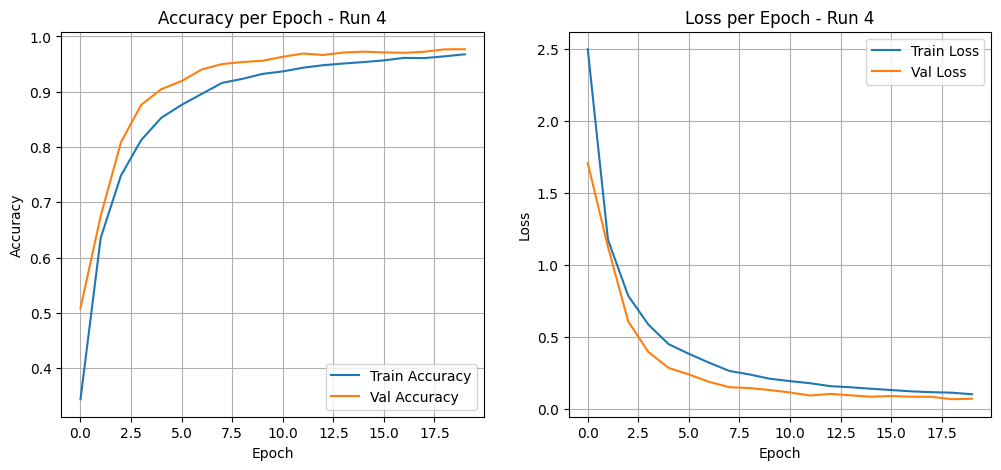

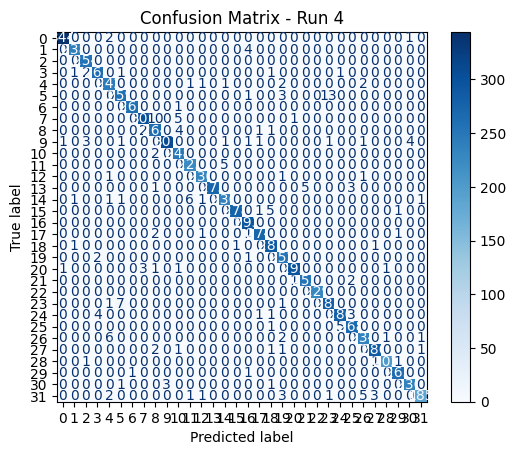


🚀 Run 5/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


534/534 ━━━━━━━━━━━━━━━━━━━━ 74s 113ms/step - accuracy: 0.2075 - loss: 3.2842 - val_accuracy: 0.4618 - val_loss: 1.8983 - learning_rate: 1.0000e-04
Epoch 2/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 49s 92ms/step - accuracy: 0.6025 - loss: 1.2873 - val_accuracy: 0.6515 - val_loss: 1.2381 - learning_rate: 1.0000e-04
Epoch 3/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 49s 91ms/step - accuracy: 0.7333 - loss: 0.8289 - val_accuracy: 0.7645 - val_loss: 0.8100 - learning_rate: 1.0000e-04
Epoch 4/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 50s 94ms/step - accuracy: 0.8029 - loss: 0.6121 - val_accuracy: 0.8684 - val_loss: 0.4080 - learning_rate: 1.0000e-04
Epoch 5/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 50s 93ms/step - accuracy: 0.8462 - loss: 0.4765 - val_accuracy: 0.9088 - val_loss: 0.2788 - learning_rate: 1.0000e-04
Epoch 6/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 49s 92ms/step - accuracy: 0.8766 - loss: 0.3779 - val_accuracy: 0.9277 - val_loss: 0.2156 - learning_rate: 1.0000e-04
Epoch 7/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 48s 90ms/step - accura

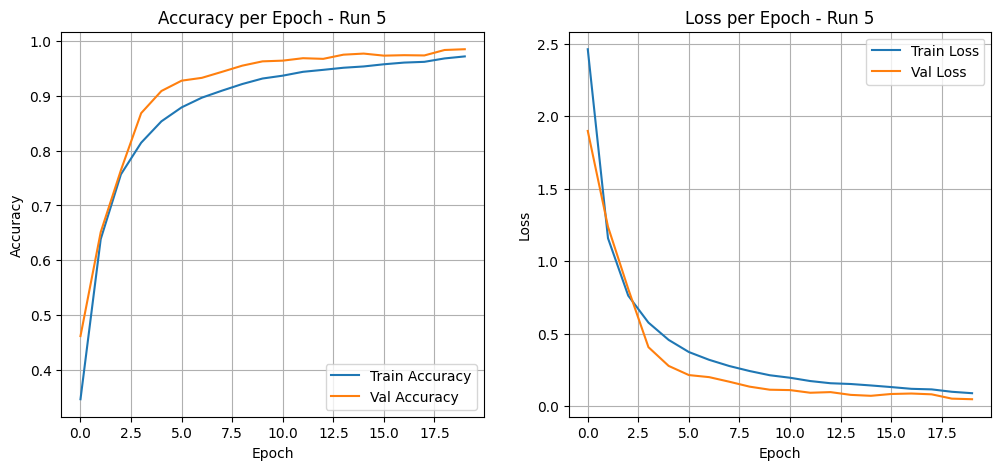

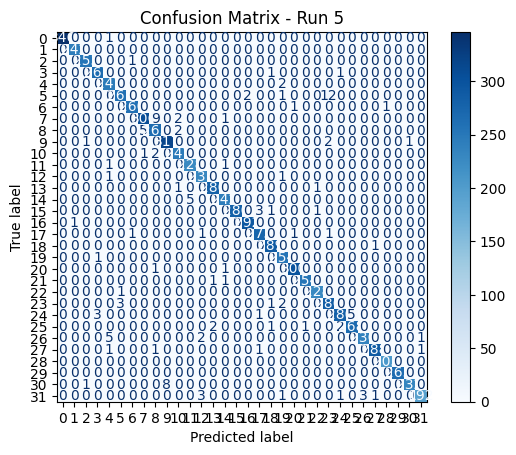


🚀 Run 6/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


534/534 ━━━━━━━━━━━━━━━━━━━━ 75s 116ms/step - accuracy: 0.2075 - loss: 3.3440 - val_accuracy: 0.4462 - val_loss: 1.9695 - learning_rate: 1.0000e-04
Epoch 2/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 51s 95ms/step - accuracy: 0.5966 - loss: 1.3088 - val_accuracy: 0.6684 - val_loss: 1.1065 - learning_rate: 1.0000e-04
Epoch 3/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 50s 93ms/step - accuracy: 0.7264 - loss: 0.8562 - val_accuracy: 0.7946 - val_loss: 0.6545 - learning_rate: 1.0000e-04
Epoch 4/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 50s 94ms/step - accuracy: 0.7974 - loss: 0.6385 - val_accuracy: 0.8681 - val_loss: 0.4094 - learning_rate: 1.0000e-04
Epoch 5/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 51s 96ms/step - accuracy: 0.8458 - loss: 0.4778 - val_accuracy: 0.8978 - val_loss: 0.3187 - learning_rate: 1.0000e-04
Epoch 6/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 51s 96ms/step - accuracy: 0.8766 - loss: 0.3881 - val_accuracy: 0.9194 - val_loss: 0.2484 - learning_rate: 1.0000e-04
Epoch 7/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 51s 96ms/step - accura

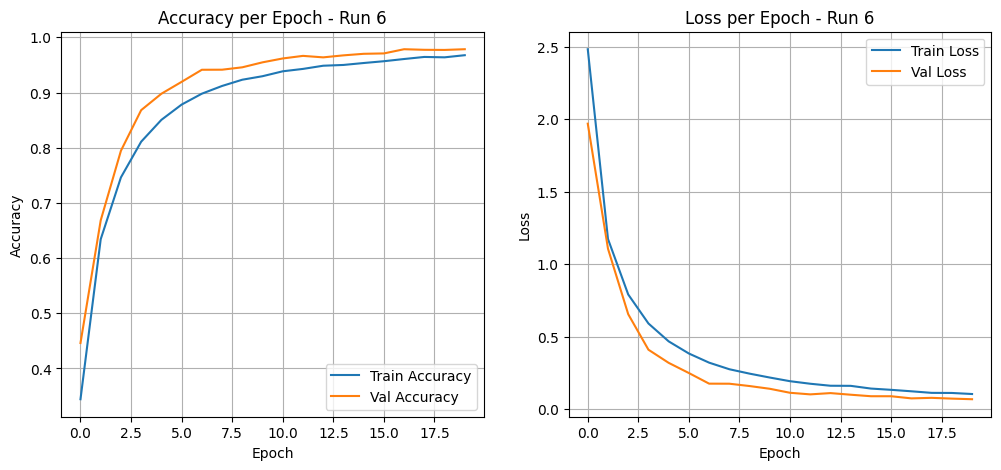

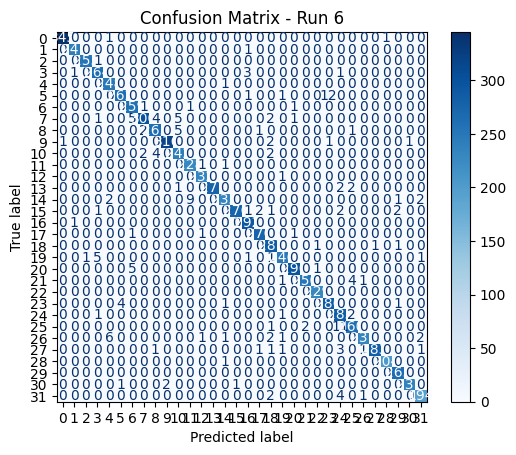


🚀 Run 7/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


534/534 ━━━━━━━━━━━━━━━━━━━━ 76s 116ms/step - accuracy: 0.2030 - loss: 3.3384 - val_accuracy: 0.4794 - val_loss: 1.7887 - learning_rate: 1.0000e-04
Epoch 2/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 50s 93ms/step - accuracy: 0.5944 - loss: 1.3363 - val_accuracy: 0.6758 - val_loss: 1.0757 - learning_rate: 1.0000e-04
Epoch 3/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 52s 97ms/step - accuracy: 0.7290 - loss: 0.8625 - val_accuracy: 0.8066 - val_loss: 0.6135 - learning_rate: 1.0000e-04
Epoch 4/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 83s 98ms/step - accuracy: 0.7985 - loss: 0.6203 - val_accuracy: 0.8809 - val_loss: 0.3577 - learning_rate: 1.0000e-04
Epoch 5/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 51s 95ms/step - accuracy: 0.8438 - loss: 0.4851 - val_accuracy: 0.9015 - val_loss: 0.3008 - learning_rate: 1.0000e-04
Epoch 6/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 51s 95ms/step - accuracy: 0.8744 - loss: 0.3904 - val_accuracy: 0.9233 - val_loss: 0.2321 - learning_rate: 1.0000e-04
Epoch 7/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 51s 95ms/step - accura

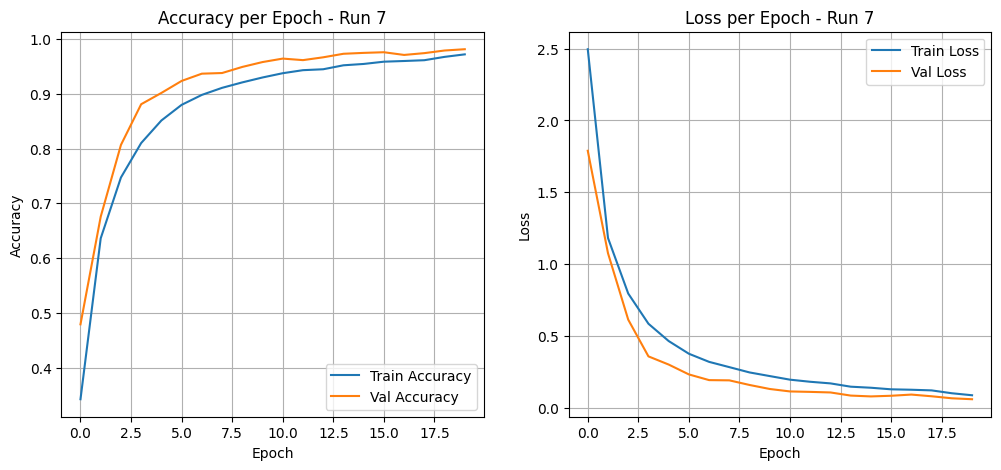

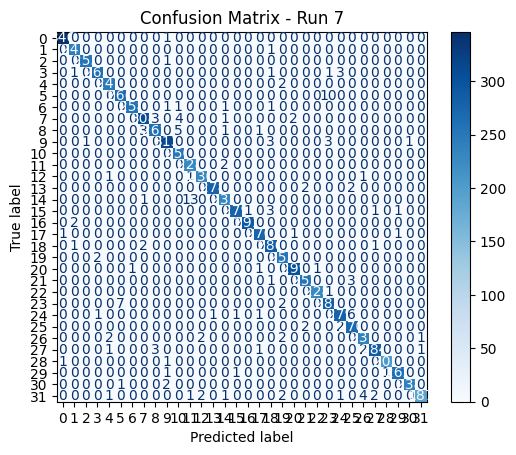


🚀 Run 8/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


534/534 ━━━━━━━━━━━━━━━━━━━━ 76s 118ms/step - accuracy: 0.2070 - loss: 3.3261 - val_accuracy: 0.5178 - val_loss: 1.5335 - learning_rate: 1.0000e-04
Epoch 2/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 51s 95ms/step - accuracy: 0.6040 - loss: 1.2829 - val_accuracy: 0.7186 - val_loss: 0.8942 - learning_rate: 1.0000e-04
Epoch 3/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 50s 94ms/step - accuracy: 0.7320 - loss: 0.8405 - val_accuracy: 0.8209 - val_loss: 0.5481 - learning_rate: 1.0000e-04
Epoch 4/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 52s 97ms/step - accuracy: 0.7990 - loss: 0.6243 - val_accuracy: 0.8693 - val_loss: 0.3930 - learning_rate: 1.0000e-04
Epoch 5/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 52s 98ms/step - accuracy: 0.8443 - loss: 0.4766 - val_accuracy: 0.9011 - val_loss: 0.3103 - learning_rate: 1.0000e-04
Epoch 6/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 51s 96ms/step - accuracy: 0.8713 - loss: 0.4001 - val_accuracy: 0.9239 - val_loss: 0.2391 - learning_rate: 1.0000e-04
Epoch 7/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 52s 97ms/step - accura

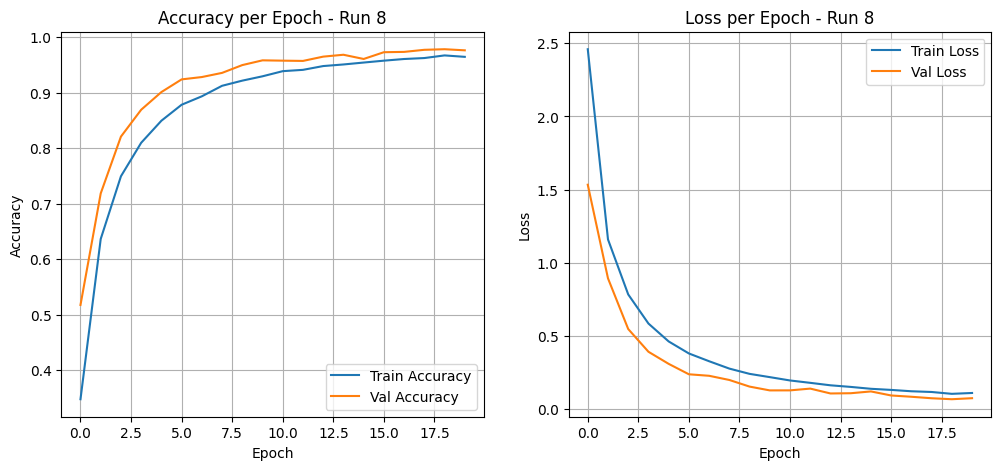

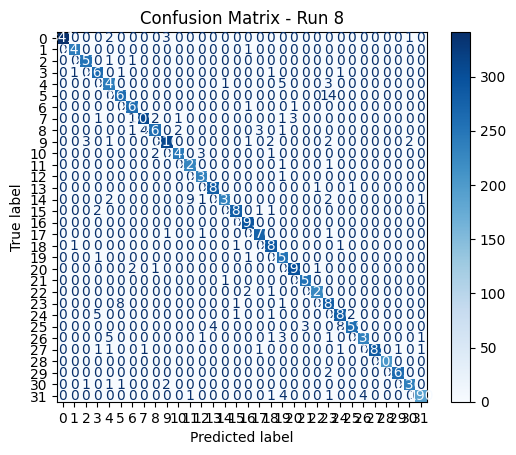


🚀 Run 9/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 77s 119ms/step - accuracy: 0.2048 - loss: 3.3498 - val_accuracy: 0.5291 - val_loss: 1.5979 - learning_rate: 1.0000e-04
Epoch 2/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 55s 103ms/step - accuracy: 0.6035 - loss: 1.2904 - val_accuracy: 0.7079 - val_loss: 0.9849 - learning_rate: 1.0000e-04
Epoch 3/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 54s 100ms/step - accuracy: 0.7324 - loss: 0.8408 - val_accuracy: 0.8121 - val_loss: 0.5954 - learning_rate: 1.0000e-04
Epoch 4/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 53s 99ms/step - accuracy: 0.7998 - loss: 0.6226 - val_accuracy: 0.8588 - val_loss: 0.4421 - learning_rate: 1.0000e-04
Epoch 5/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.8467 - loss: 0.4760 - val_accuracy: 0.9118 - val_loss: 0.2701 - learning_rate: 1.0000e-04
Epoch 6/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 52s 96ms/step - accuracy: 0.8726 - loss: 0.4027 - val_accuracy: 0.9169 - val_loss: 0.2623 - learning_rate: 1.0000e-04
Epoch 7/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 52s 97ms/

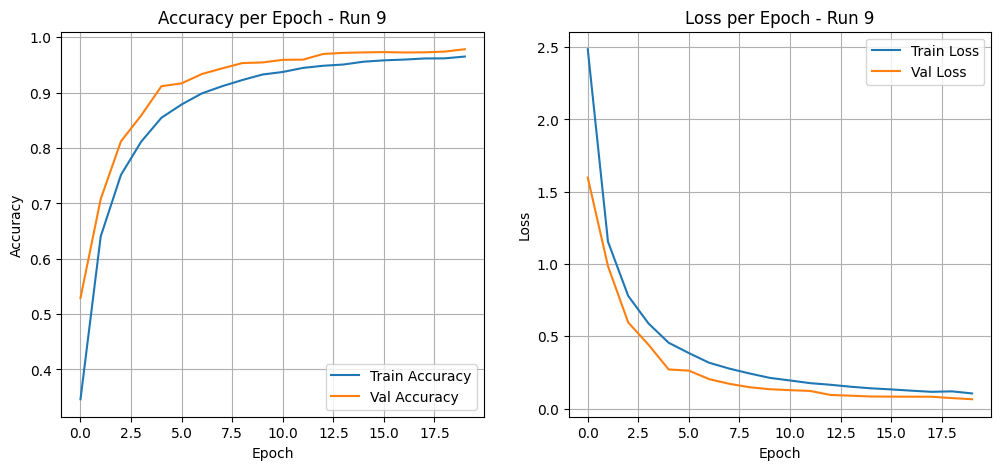

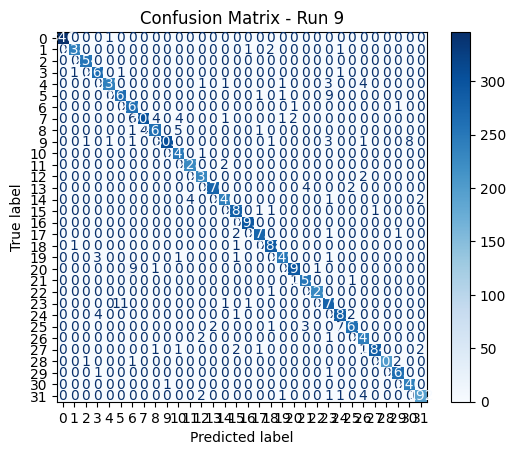


🚀 Run 10/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


534/534 ━━━━━━━━━━━━━━━━━━━━ 78s 122ms/step - accuracy: 0.2071 - loss: 3.3327 - val_accuracy: 0.4915 - val_loss: 1.6902 - learning_rate: 1.0000e-04
Epoch 2/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 65s 102ms/step - accuracy: 0.6004 - loss: 1.2980 - val_accuracy: 0.7375 - val_loss: 0.8349 - learning_rate: 1.0000e-04
Epoch 3/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 82s 102ms/step - accuracy: 0.7297 - loss: 0.8477 - val_accuracy: 0.8382 - val_loss: 0.4974 - learning_rate: 1.0000e-04
Epoch 4/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 54s 101ms/step - accuracy: 0.7998 - loss: 0.6273 - val_accuracy: 0.8849 - val_loss: 0.3540 - learning_rate: 1.0000e-04
Epoch 5/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 54s 101ms/step - accuracy: 0.8455 - loss: 0.4762 - val_accuracy: 0.9157 - val_loss: 0.2500 - learning_rate: 1.0000e-04
Epoch 6/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 54s 100ms/step - accuracy: 0.8727 - loss: 0.3945 - val_accuracy: 0.9224 - val_loss: 0.2338 - learning_rate: 1.0000e-04
Epoch 7/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 54s 100ms/step - 

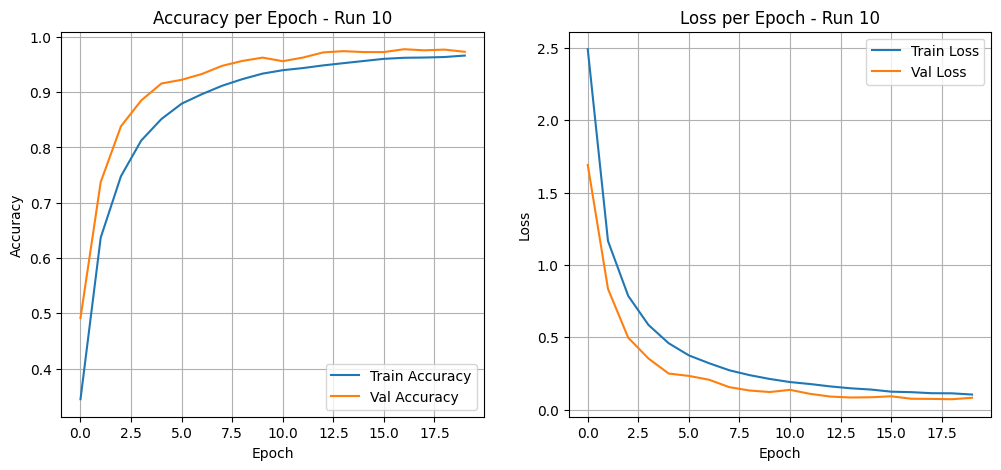

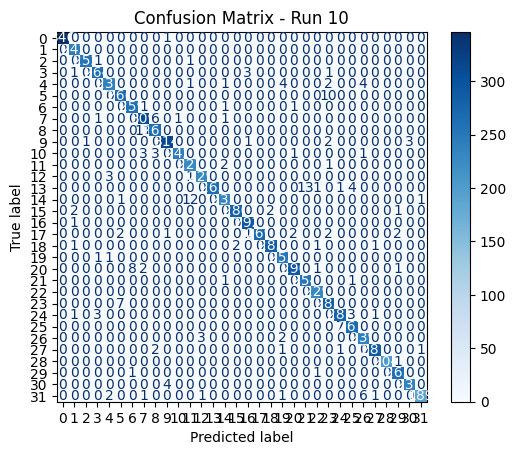


✅ جميع النتائج بعد 10 Runs:
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC  F1_Weighted  \
0    1      0.976826  0.069414  0.976081  0.999882     0.976841   
1    2      0.977645  0.070262  0.976925  0.999877     0.977641   
2    3      0.978464  0.066109  0.977772  0.999900     0.978475   
3    4      0.976592  0.069250  0.975834  0.999895     0.976584   
4    5      0.985019  0.049221  0.984533  0.999921     0.985009   
5    6      0.978464  0.067706  0.977770  0.999900     0.978467   
6    7      0.981156  0.059518  0.980545  0.999913     0.981153   
7    8      0.978230  0.068895  0.977527  0.999884     0.978250   
8    9      0.978581  0.064357  0.977891  0.999915     0.978586   
9   10      0.977060  0.072770  0.976319  0.999881     0.977065   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Used(MB)  
0            0.977261         0.976826       1093.022180      1312.269531  
1            0.978006         0.977645        988.173548       468.617188  
2    

In [ ]:
import gc, time, psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K
from sklearn.metrics import (matthews_corrcoef, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, precision_score, recall_score)
from sklearn.preprocessing import label_binarize
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

results = []

for run in range(1, 11):  # 10 runs
    print(f"\n🚀 Run {run}/10")

    # --- قياس الوقت والذاكرة قبل التدريب ---
    start_time = time.time()
    start_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB

    # --- بناء الموديل ---
    model = build_mobilenetv2(input_shape, num_classes)

    early_stop = EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss')
    lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)

    # --- تدريب الموديل ---
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=64),
        validation_data=(X_val, y_val),
        epochs=20,
        callbacks=[early_stop, lr_reduce],
        verbose=1
    )

    # --- قياس الوقت والذاكرة بعد التدريب ---
    end_time = time.time()
    end_mem = psutil.Process().memory_info().rss / (1024 ** 2)
    train_time = end_time - start_time
    train_memory = end_mem - start_mem

    # --- تقييم الموديل ---
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    # --- تنبؤ ---
    y_pred_probs = model.predict(X_val, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # --- MCC ---
    mcc = matthews_corrcoef(y_val, y_pred)

    # --- ROC AUC ---
    y_val_bin = label_binarize(y_val, classes=np.arange(num_classes))
    try:
        roc_auc = roc_auc_score(y_val_bin, y_pred_probs, average='macro', multi_class='ovr')
    except:
        roc_auc = np.nan

    # --- Weighted Metrics ---
    f1_w = f1_score(y_val, y_pred, average='weighted')
    precision_w = precision_score(y_val, y_pred, average='weighted')
    recall_w = recall_score(y_val, y_pred, average='weighted')

    # --- حفظ النتيجة ---
    run_result = {
        "Run": run,
        "Val_Accuracy": val_acc,
        "Val_Loss": val_loss,
        "MCC": mcc,
        "ROC_AUC": roc_auc,
        "F1_Weighted": f1_w,
        "Precision_Weighted": precision_w,
        "Recall_Weighted": recall_w,
        "Training_Time(s)": train_time,
        "Memory_Used(MB)": train_memory
    }
    results.append(run_result)

    print(f"\n📊 Results Run {run}: "
          f"Acc={val_acc:.4f}, Loss={val_loss:.4f}, MCC={mcc:.4f}, "
          f"ROC_AUC={roc_auc:.4f}, F1={f1_w:.4f}, "
          f"Prec={precision_w:.4f}, Recall={recall_w:.4f}, "
          f"Time={train_time:.2f}s, Mem={train_memory:.2f}MB")

    # --- رسم Accuracy و Loss لكل Epoch ---
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'Accuracy per Epoch - Run {run}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Loss per Epoch - Run {run}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Run {run}")
    plt.show()

    # --- تنظيف الميموري ---
    del model, history, y_pred, y_pred_probs
    K.clear_session()
    gc.collect()

# --- تحويل ل DataFrame ---
df_results = pd.DataFrame(results)
print("\n✅ جميع النتائج بعد 10 Runs:")
print(df_results)

# --- حفظ النتائج ---
df_results.to_excel("mobilenetv2_metrics_results.xlsx", index=False)
print("\n💾 Saved to mobilenetv2_metrics_results.xlsx")


In [ ]:
df_results = pd.DataFrame(results)
df_results.to_excel('/content/drive/MyDrive/Mobilenet_original.xlsx', index=False)
print("✅ Results saved to CNN_Lstm_original_analysis.xlsx")
print(df_results)


✅ Results saved to CNN_Lstm_original_analysis.xlsx
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC  F1_Weighted  \
0    1      0.976826  0.069414  0.976081  0.999882     0.976841   
1    2      0.977645  0.070262  0.976925  0.999877     0.977641   
2    3      0.978464  0.066109  0.977772  0.999900     0.978475   
3    4      0.976592  0.069250  0.975834  0.999895     0.976584   
4    5      0.985019  0.049221  0.984533  0.999921     0.985009   
5    6      0.978464  0.067706  0.977770  0.999900     0.978467   
6    7      0.981156  0.059518  0.980545  0.999913     0.981153   
7    8      0.978230  0.068895  0.977527  0.999884     0.978250   
8    9      0.978581  0.064357  0.977891  0.999915     0.978586   
9   10      0.977060  0.072770  0.976319  0.999881     0.977065   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Used(MB)  
0            0.977261         0.976826       1093.022180      1312.269531  
1            0.978006         0.977645        988.173548   

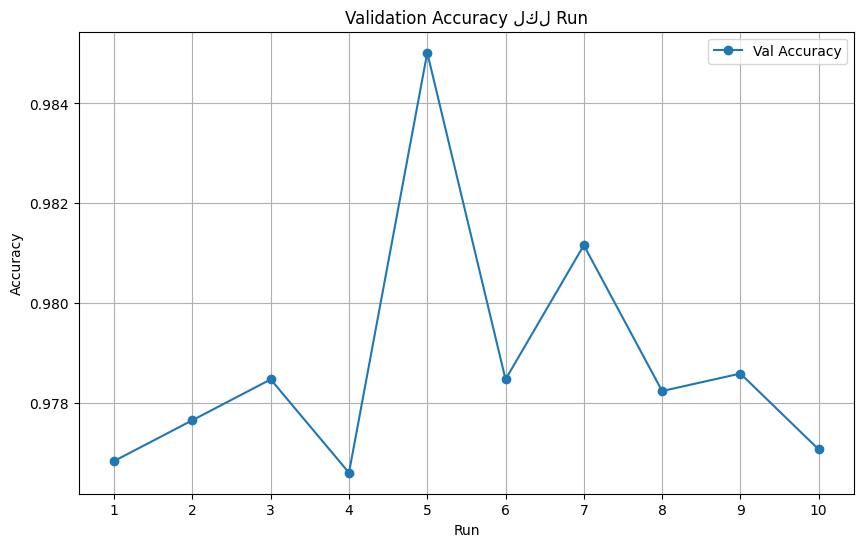

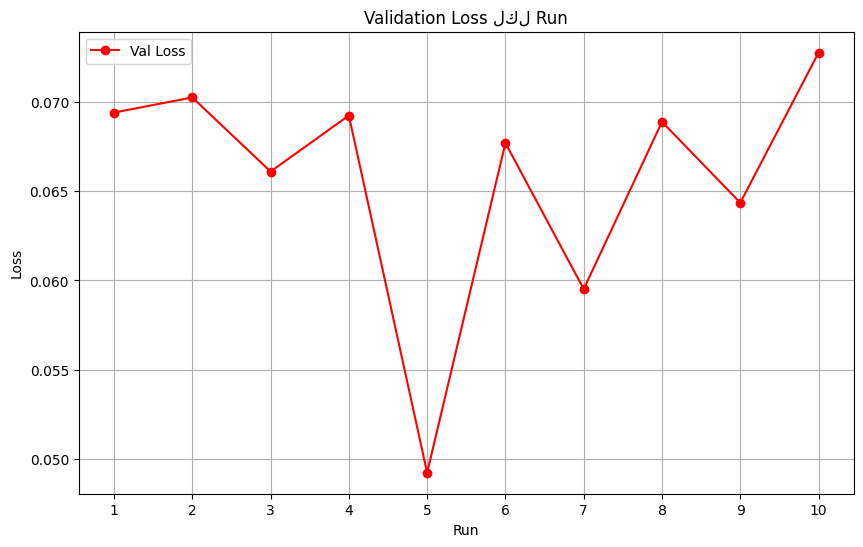

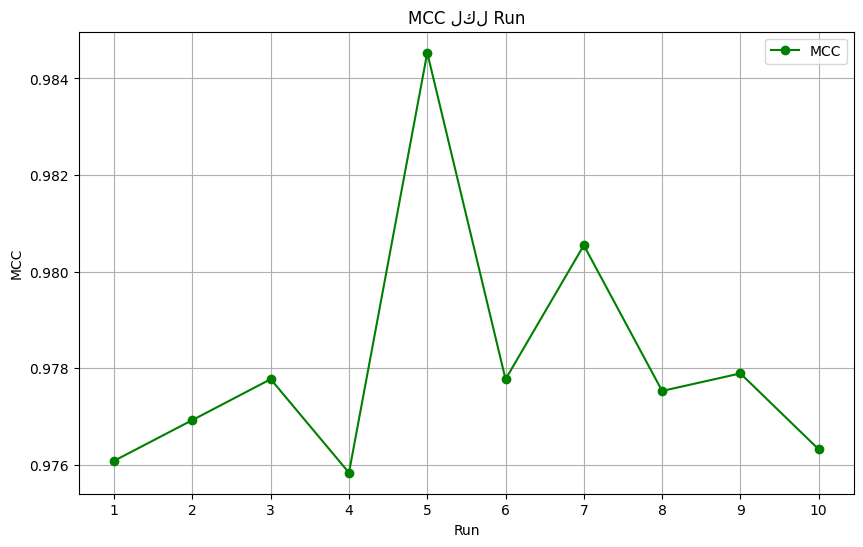

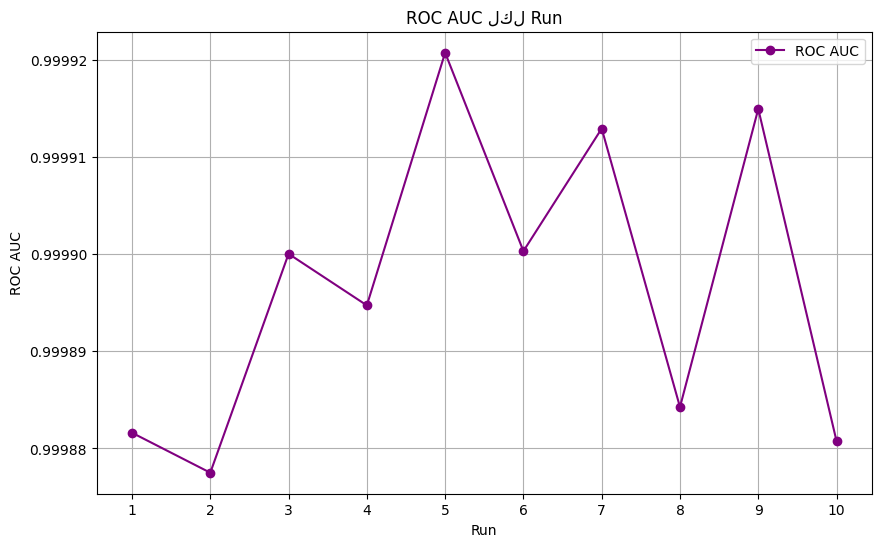

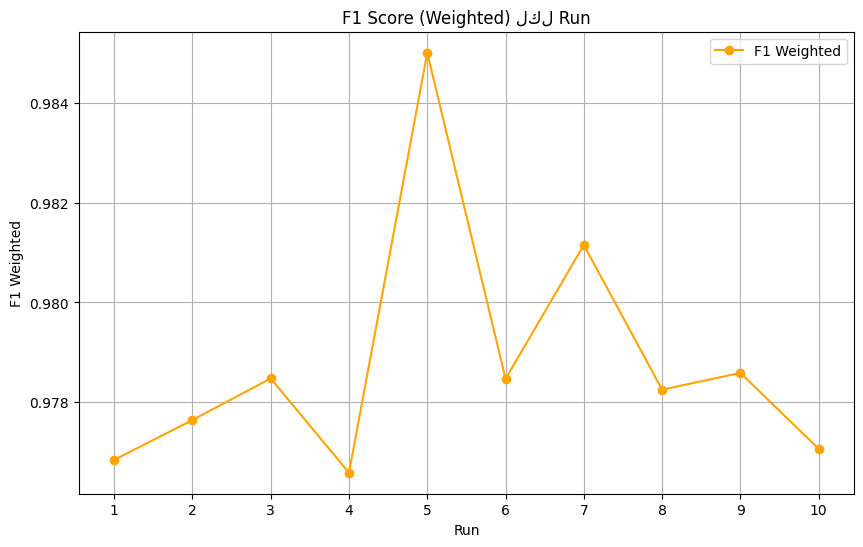

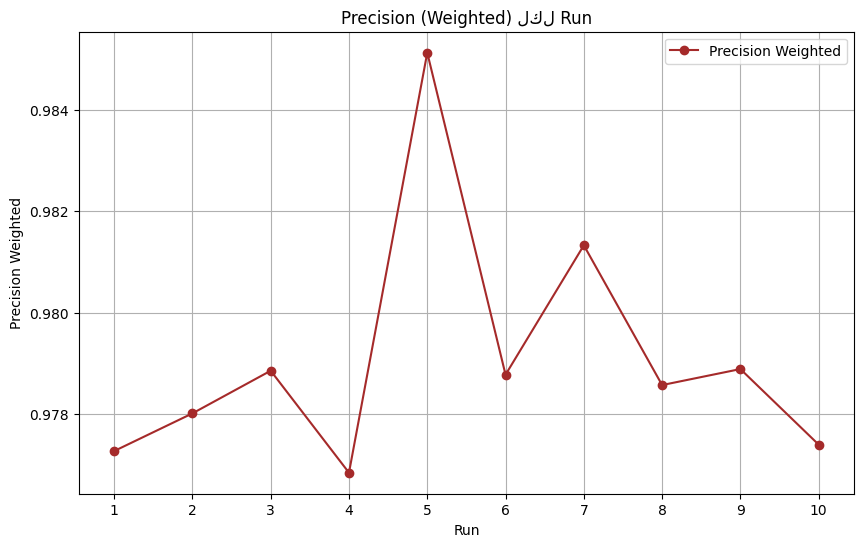

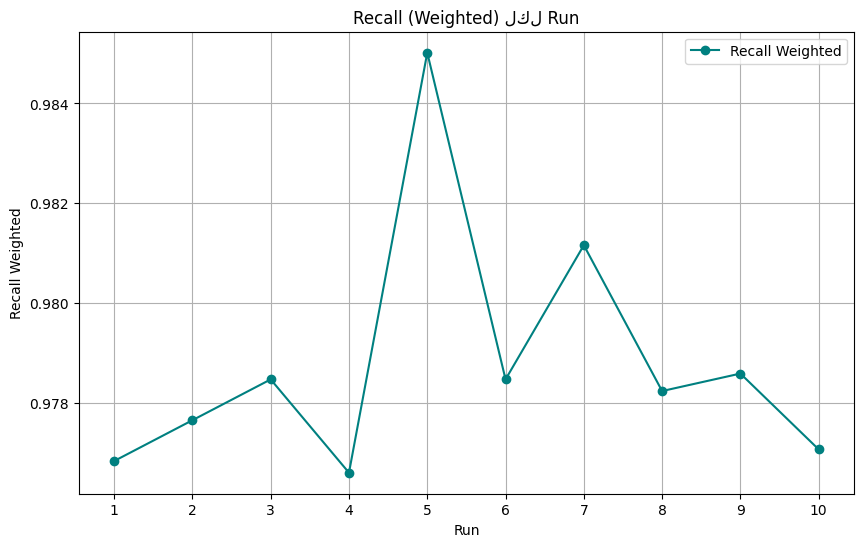

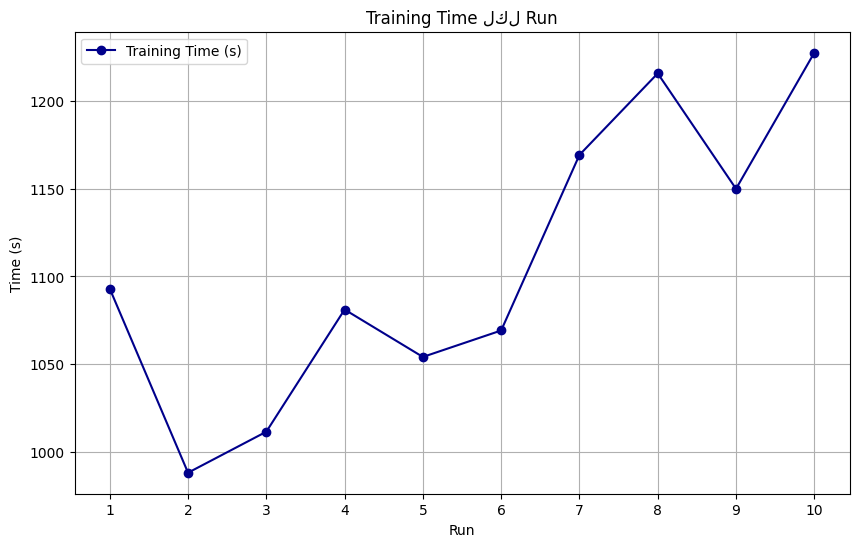

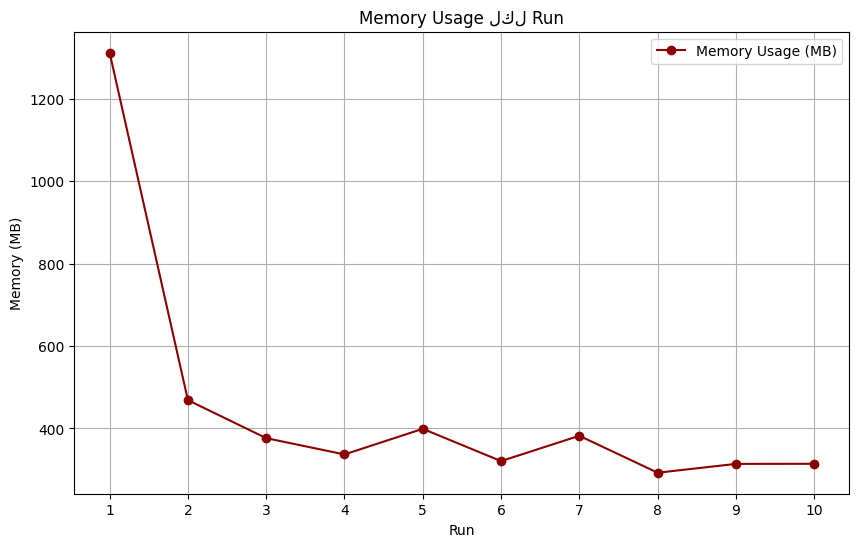

In [ ]:
import matplotlib.pyplot as plt

# --- رسم Accuracy لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Val_Accuracy'], marker='o', label='Val Accuracy')
plt.title("Validation Accuracy لكل Run")
plt.xlabel("Run")
plt.ylabel("Accuracy")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Loss لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Val_Loss'], marker='o', color='red', label='Val Loss')
plt.title("Validation Loss لكل Run")
plt.xlabel("Run")
plt.ylabel("Loss")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم MCC لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['MCC'], marker='o', color='green', label='MCC')
plt.title("MCC لكل Run")
plt.xlabel("Run")
plt.ylabel("MCC")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم ROC_AUC لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['ROC_AUC'], marker='o', color='purple', label='ROC AUC')
plt.title("ROC AUC لكل Run")
plt.xlabel("Run")
plt.ylabel("ROC AUC")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()
# --- رسم F1 لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['F1_Weighted'], marker='o', color='orange', label='F1 Weighted')
plt.title("F1 Score (Weighted) لكل Run")
plt.xlabel("Run")
plt.ylabel("F1 Weighted")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Precision لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Precision_Weighted'], marker='o', color='brown', label='Precision Weighted')
plt.title("Precision (Weighted) لكل Run")
plt.xlabel("Run")
plt.ylabel("Precision Weighted")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Recall لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Recall_Weighted'], marker='o', color='teal', label='Recall Weighted')
plt.title("Recall (Weighted) لكل Run")
plt.xlabel("Run")
plt.ylabel("Recall Weighted")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Training Time لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Training_Time(s)'], marker='o', color='darkblue', label='Training Time (s)')
plt.title("Training Time لكل Run")
plt.xlabel("Run")
plt.ylabel("Time (s)")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Memory Usage لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Memory_Used(MB)'], marker='o', color='darkred', label='Memory Usage (MB)')
plt.title("Memory Usage لكل Run")
plt.xlabel("Run")
plt.ylabel("Memory (MB)")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()



📊 Average Results across all runs:
Average Accuracy        : 0.9788
Average Loss            : 0.0658
Average MCC             : 0.9781
Average ROC AUC         : 0.9999
Average F1_Weighted     : 0.9788
Average Precision_W     : 0.9791
Average Recall_W        : 0.9788
Average Training Time(s): 1105.94
Average Memory Used(MB) : 451.60

✅ Results saved to /content/drive/MyDrive/CNN_Lstm_results_original_average.xlsx


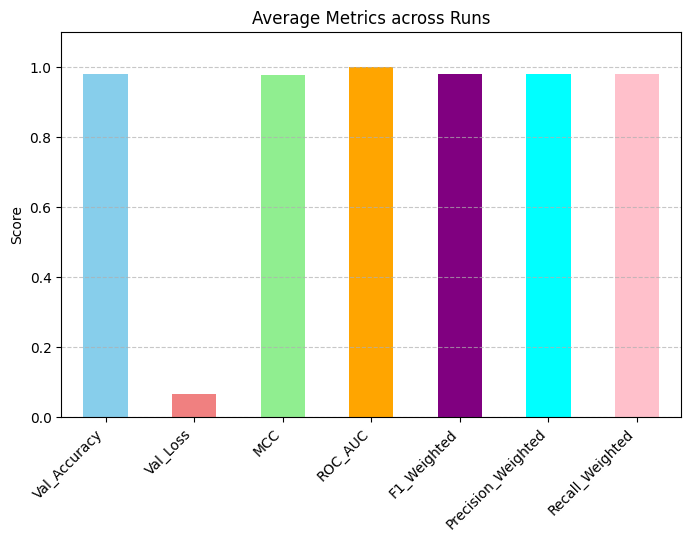

In [ ]:
import matplotlib.pyplot as plt

# --- تحويل النتائج ل DataFrame ---
results_df = pd.DataFrame(results)

# --- حساب المتوسط لكل مقياس ---
avg_results = results_df.mean(numeric_only=True)

print("\n📊 Average Results across all runs:")
print(f"Average Accuracy        : {avg_results['Val_Accuracy']:.4f}")
print(f"Average Loss            : {avg_results['Val_Loss']:.4f}")
print(f"Average MCC             : {avg_results['MCC']:.4f}")
print(f"Average ROC AUC         : {avg_results['ROC_AUC']:.4f}")
print(f"Average F1_Weighted     : {avg_results['F1_Weighted']:.4f}")
print(f"Average Precision_W     : {avg_results['Precision_Weighted']:.4f}")
print(f"Average Recall_W        : {avg_results['Recall_Weighted']:.4f}")
print(f"Average Training Time(s): {avg_results['Training_Time(s)']:.2f}")
print(f"Average Memory Used(MB) : {avg_results['Memory_Used(MB)']:.2f}")

# --- حفظ النتائج في Excel ---
save_path = "/content/drive/MyDrive/CNN_Lstm_results_original_average.xlsx"
with pd.ExcelWriter(save_path) as writer:
    results_df.to_excel(writer, sheet_name="All Runs", index=False)
    avg_results.to_frame(name="Average").to_excel(writer, sheet_name="Average")

print(f"\n✅ Results saved to {save_path}")

# --- رسم المتوسطات (المقاييس من 0 لـ 1 فقط) ---
plt.figure(figsize=(8,5))
avg_results[['Val_Accuracy','Val_Loss','MCC','ROC_AUC','F1_Weighted','Precision_Weighted','Recall_Weighted']].plot(
    kind='bar',
    color=['skyblue','lightcoral','lightgreen','orange','purple','cyan','pink']
)
plt.title("Average Metrics across Runs")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)  # معظم المقاييس بتبقى بين 0 و 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=468060f647d91c18e4d8dd6030be7b3a7d7d515d95b845f3b603e4165c7cfc94
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
📐 Sequential Input Shape: T=10 × 64x64x1


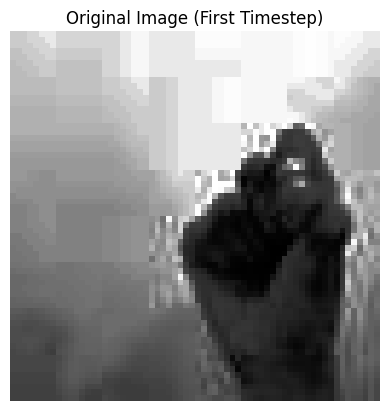

Predicted class: fa (0.90)


  0%|          | 0/1000 [00:00<?, ?it/s]

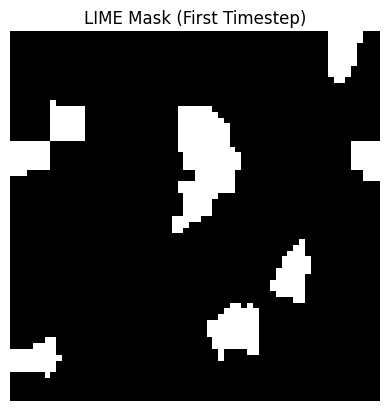

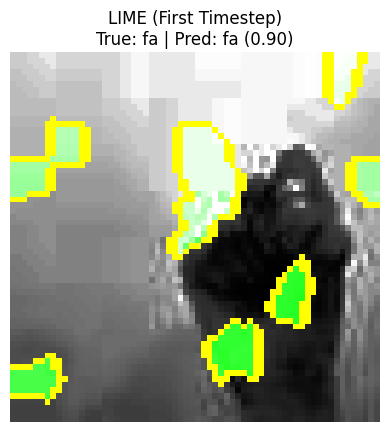

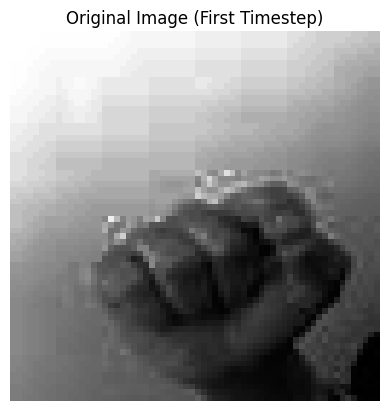

Predicted class: fa (0.99)


  0%|          | 0/1000 [00:00<?, ?it/s]

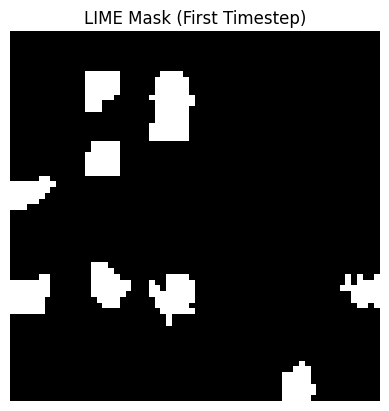

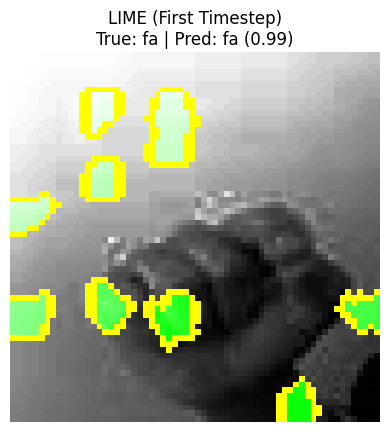

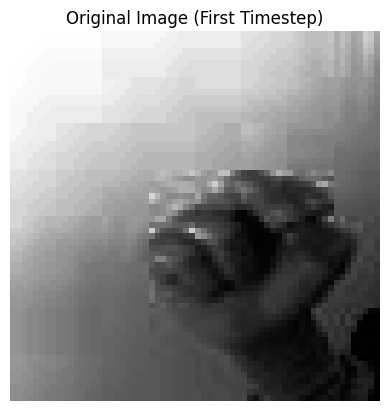

Predicted class: gaaf (0.98)


  0%|          | 0/1000 [00:00<?, ?it/s]

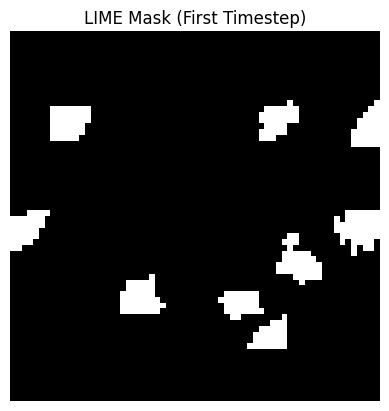

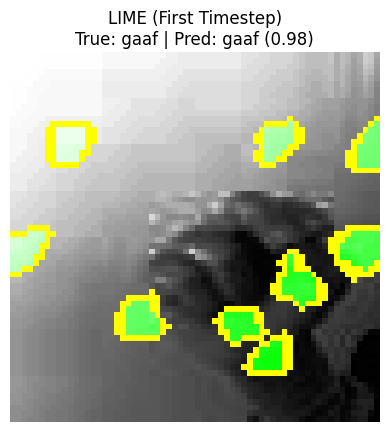

In [ ]:
!pip install lime
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from skimage.transform import resize
from skimage.color import rgb2gray  # Add for grayscale conversion

# تحميل أسماء الكلاسات
class_names = np.load('/content/drive/MyDrive/label_encoder_classes.npy', allow_pickle=True)

# استخراج شكل مدخلات الموديل
full_input_shape = model.input_shape  # e.g., (None, 10, 64, 64, 1)
input_shape = full_input_shape[1:]    # Remove batch dim: e.g., (10, 64, 64, 1)

T = 1
if len(input_shape) == 4 and input_shape[0] == 10 and input_shape[-1] == 1:
    T, H, W, C = input_shape  # T=10 timesteps, H/W=64, C=1 (grayscale)
    print(f"📐 Sequential Input Shape: T={T} × {H}x{W}x{C}")
elif len(input_shape) == 1:
    # 1D input (flattened): infer H, W, C assuming square grayscale (C=1) or adjust as needed
    features = input_shape[0]
    H = int(np.sqrt(features))  # Assume square; adjust if rectangular
    W = H
    C = 1  # Grayscale; set to 3 if flattened RGB
    print(f"📐 Inferred Input Shape (flattened): T={T} × {H}x{W}x{C} (total features: {features})")
elif len(input_shape) == 3:
    H, W, C = input_shape
    print(f"📐 Input Shape: T={T} × {H}x{W}x{C}")
else:
    raise ValueError(f"Unsupported input shape: {input_shape}")

# دالة تجهيز الصور زي التدريب (updated for sequential input)
def preprocess_batch(images):
    # images: list of data items, each potentially (T, H, W, C) or raw
    out = []
    for item in images:
        item = np.asarray(item)
        if item.ndim == 4 and item.shape == input_shape:  # Already (T, H, W, 1)
            im = item
        elif item.ndim == 2:  # Grayscale 2D: expand to (T, H, W, 1)
            im = np.expand_dims(item, axis=(0, -1))  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)  # Duplicate across timesteps if input is static
        elif item.ndim == 3 and item.shape[-1] == 1:  # (H, W, 1): expand to (T, H, W, 1)
            im = np.expand_dims(item, axis=0)  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)
        elif item.ndim == 3 and item.shape[-1] == 3:  # RGB image: convert to grayscale first
            gray = rgb2gray(item)  # Convert to (H, W)
            im = np.expand_dims(gray, axis=(0, -1))  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)  # Duplicate across timesteps
        else:
            # Fallback: assume it's the full sequence or handle differently
            if item.ndim == 5 and item.shape[1:] == input_shape:
                im = item[0]  # Take first batch if accidentally batched
            else:
                raise ValueError(f"Unexpected item shape: {item.shape}")

        # Resize each timestep if needed (preserves T)
        resized = np.zeros(input_shape, dtype='float32')
        for t in range(T):
            frame = im[t, :, :, 0] if C == 1 else im[t]
            frame_resized = resize(frame, (H, W), preserve_range=True, anti_aliasing=True).astype('float32')
            resized[t, :, :, 0] = frame_resized
        im = resized

        if im.max() > 1.0:
            im = im / 255.0
        out.append(im)
    return np.asarray(out, dtype='float32')

# دالة التنبؤ لـ LIME
def predict_fn(images):
    Xb = preprocess_batch(images)
    return model.predict(Xb, verbose=0)

# إنشاء مفسر LIME
explainer = lime_image.LimeImageExplainer()

# اختيار صور عشوائية للتفسير
indices = np.random.choice(len(X_val), size=3, replace=False)

for idx in indices:
    data_item = X_val[idx]  # Assume (T, H, W, C)

    # تجهيز نسخة RGB للعرض (use first timestep as representative)
    if data_item.ndim == 4:
        frame = data_item[0]  # First timestep
    else:
        frame = data_item
    if frame.ndim == 2 or frame.shape[-1] == 1:
        image_rgb = np.repeat(frame[..., np.newaxis], 3, axis=-1)
        image_rgb = np.squeeze(image_rgb)
    else:
        image_rgb = frame[..., :3]

    # --- عرض الصورة الأصلية (first frame) ---
    plt.figure()
    plt.imshow(image_rgb, cmap='gray' if C == 1 else None)
    plt.title("Original Image (First Timestep)")
    plt.axis('off')
    plt.show()

    # --- تنبؤ الموديل ---
    pred_probs = model.predict(preprocess_batch([data_item]), verbose=0)[0]
    pred_label = int(np.argmax(pred_probs))
    print(f"Predicted class: {class_names[pred_label]} ({pred_probs[pred_label]:.2f})")

    # --- تفسير LIME (on first frame as static image) ---
    explanation = explainer.explain_instance(
        image_rgb.astype('double'),  # Use double for precision
        predict_fn,
        labels=[pred_label],
        hide_color=0,
        num_samples=1000,
        segmentation_fn=slic
    )

    # --- استخراج الـ mask ---
    temp, mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    # --- عرض الـ mask ---
    plt.figure()
    plt.imshow(mask, cmap='gray')
    plt.title("LIME Mask (First Timestep)")
    plt.axis('off')
    plt.show()

    # --- عرض الصورة مع الحدود ---
    true_class_name = class_names[int(y_val[idx])]
    predicted_class_name = class_names[pred_label]
    plt.figure()
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME (First Timestep)\nTrue: {true_class_name} | Pred: {predicted_class_name} ({pred_probs[pred_label]:.2f})")
    plt.axis('off')
    plt.show()

In [ ]:
import numpy as np

# حفظ الموديل بصيغة Keras الجديدة
model.save('/content/drive/MyDrive/my_modelmobilenet_original.keras')

# حفظ بيانات validation (لو محتاجة تكمل عليها)
np.save('/content/drive/MyDrive/alphabet/x_val_mobilenet_original.npy', X_val)
np.save('/content/drive/MyDrive/alphabet/y_val_mobilenet_original.npy', y_val)
